In [1]:
import matplotlib.pyplot as plt
import graph_style as gs
gs.set_graph_style(1)


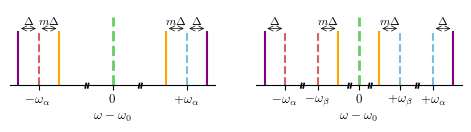

In [34]:
mode = 1.8
mode_2 = 1.0

d = 0.5
m = 1
ym = yd = 0.7

fig_width = gs.get_fig_width()
fig, axs = plt.subplots(
    1, 2,
    figsize=(fig_width, fig_width / 6),
    sharey=True
)

# ------------------------------------------------------------
# Define mode lines and tone positions for each plot
# ------------------------------------------------------------

mode_lines = [
    [-mode, mode],
    [-mode, mode, -mode_2, mode_2],
]

tones = [
    [-mode - d, -mode + m*d,     mode - m*d,     mode + d],
    [-mode - d, -mode_2 + m*d,   mode_2 - m*d,   mode + d],
]

tone_colors = ["purple", "orange", "orange", "purple"]

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

for ax, modes, tone_pos in zip(axs, mode_lines, tones):

    # Central line
    ax.axvline(
        0, ymax=0.9, lw=2,
        color=gs.get_color(1)
    )

    # Mode lines
    for x in modes:
        color = gs.get_color(2) if x < 0 else gs.get_color(5)
        ax.axvline(
            x, ls="--", lw=1.5, ymax=ym,
            color=color
        )

    # Tones
    for x, color in zip(tone_pos, tone_colors):
        ax.axvline(
            x, lw=1.5, ymax=yd,
            color=color, linestyle="-"
        )

    # Arrows between each tone and its corresponding mode
    arrows = [
        (tone_pos[0], -mode, r"$\Delta$"),
        (tone_pos[1], modes[-2] if len(modes) == 4 else -mode, r"$m\Delta$"),
        (modes[-1] if len(modes) == 4 else mode, tone_pos[2], r"$m\Delta$"),
        (mode, tone_pos[3], r"$\Delta$"),
    ]

    y_arrow = 1.8

    for x1, x2, label in arrows:
        ax.annotate(
            "",
            xy=(x2, y_arrow),
            xytext=(x1, y_arrow),
            arrowprops=dict(arrowstyle="<->", lw=0.5)
        )
        ax.text(
            (x1 + x2) / 2,
            y_arrow + 0.05,
            label,
            ha="center",
            va="bottom",
            fontsize=8
        )

    # Decorative axis breaks
    xbreaks = [
        tone_pos[1] / 2,
        tone_pos[2] / 2,
    ]
    if ax == axs[1]:
        xbreaks.append(mode_2 + (mode-mode_2)/2)
        xbreaks.append(-mode_2 - (mode-mode_2)/2)

    dx, dy = 0.02, 0.055

    for xb in xbreaks:
        for offset in (0, 3*dx):
            ax.plot(
                [xb - dx + offset, xb + dx + offset],
                [-dy, dy],
                transform=ax.get_xaxis_transform(),
                color="k",
                clip_on=False,
                lw=1.2
            )

    xlim = (mode+d)+0.2
    ax.set_xlim(-xlim, xlim)
    ax.set_ylim(0, 2.4)
    ax.set_yticks([])
    ax.set_xlabel(r"$\omega-\omega_0$")
    ax.grid(False)


# Plot 1 ticks
axs[0].set_xticks([-mode, 0, mode])
axs[0].set_xticklabels([
    r"$-\omega_\alpha$",
    "0",
    r"$+\omega_\alpha$"
])

# Plot 2 ticks
axs[1].set_xticks([-mode_2, -mode, 0, mode, mode_2])
axs[1].set_xticklabels([
    r"$-\omega_\beta$",
    r"$-\omega_\alpha$",
    "0",
    r"$+\omega_\alpha$",
    r"$+\omega_\beta$"
])
for ax in axs:
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

f_name = r"..\..\pdf_figure\ch6\four_tones_py.pdf"
plt.savefig(f_name, bbox_inches="tight", pad_inches=0.05)